## **Name:** Rohan Khadye

## **Roll no.:** 23102C0065

## **CMPN C**

In [ ]:
# ============================================================
# CELL 1: INSTALL R PACKAGES
# ============================================================

options(repos = c(CRAN = "https://cloud.r-project.org"))

# BiocManager
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# System dependency for EBImage
system(
  "apt-get update -qq && apt-get install -y libfftw3-dev",
  intern = TRUE
)

# EBImage
if (!requireNamespace("EBImage", quietly = TRUE)) {
  BiocManager::install(
    "EBImage",
    ask = FALSE,
    update = FALSE
  )
}

# Current Keras R interface
if (!requireNamespace("keras3", quietly = TRUE)) {
  install.packages("keras3")
}

cat("R packages installed.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Reading package lists..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
 [2] "Building dependency tree..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
 [3] "Reading state information..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
 [4] "The following additional packages will be installed:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
 [5] "  libfftw3-bin libfftw3-double3 libfftw3-long3 libfftw3-quad3 libfftw3-single3"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
 [6] "Suggested packages:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
 [7] "  libfftw3-doc"                                                                                                        

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.1 (2025-06-13)

Installing package(s) 'BiocVersion', 'EBImage'

also installing the dependencies ‘bitops’, ‘BiocGenerics’, ‘abind’, ‘tiff’, ‘jpeg’, ‘png’, ‘locfit’, ‘fftwtools’, ‘RCurl’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’, ‘dotty’




R packages installed.


In [ ]:
# ============================================================
# CELL 2: CONFIGURE PYTHON DEPENDENCIES
# ============================================================

library(reticulate)

# Force reticulate to use its managed Python environment.
Sys.setenv(RETICULATE_PYTHON = "managed")

# Declare ALL Python requirements before Python starts.
py_require(
  packages = c(
    "keras",
    "tensorflow",
    "numpy"
  ),
  python_version = ">=3.10,<3.13"
)

cat("Python requirements declared.\n")

Python requirements declared.


In [ ]:
# ============================================================
# CELL 3: LOAD KERAS 3
# ============================================================

library(keras3)

use_backend(
  "tensorflow",
  gpu = FALSE
)

cat("Keras 3 loaded.\n")

Keras 3 loaded.


In [ ]:
# ============================================================
# CELL 4: VERIFY PYTHON
# ============================================================

library(reticulate)

cat("\nPython configuration:\n")
print(py_config())

cat(
  "\nNumPy:",
  py_module_available("numpy"),
  "\n"
)

cat(
  "TensorFlow:",
  py_module_available("tensorflow"),
  "\n"
)

cat(
  "Keras:",
  py_module_available("keras"),
  "\n"
)


Python configuration:
python:         /root/.cache/uv/archive-v0/ya6HhZCJuLp_3T5TRJcKH/bin/python
libpython:      /root/.local/share/uv/python/cpython-3.11.11-linux-x86_64-gnu/lib/libpython3.11.so
pythonhome:     /root/.cache/uv/archive-v0/ya6HhZCJuLp_3T5TRJcKH:/root/.cache/uv/archive-v0/ya6HhZCJuLp_3T5TRJcKH
virtualenv:     /root/.cache/uv/archive-v0/ya6HhZCJuLp_3T5TRJcKH/bin/activate_this.py
version:        3.11.11 (main, Mar 17 2025, 21:02:09) [Clang 20.1.0 ]
numpy:          /root/.cache/uv/archive-v0/ya6HhZCJuLp_3T5TRJcKH/lib/python3.11/site-packages/numpy
numpy_version:  2.4.6
keras:          /root/.cache/uv/archive-v0/ya6HhZCJuLp_3T5TRJcKH/lib/python3.11/site-packages/keras

NOTE: Python version was forced by py_require()

NumPy: TRUE 
TensorFlow: TRUE 
Keras: TRUE 


In [ ]:
# ============================================================
# CELL 5: TEST KERAS
# ============================================================

x <- c(0, 1)

x_onehot <- to_categorical(
  x,
  num_classes = 2
)

print(x_onehot)

     [,1] [,2]
[1,]    1    0
[2,]    0    1


In [ ]:
# ============================================================
# CELL 6: LOAD EBIMAGE
# ============================================================

library(EBImage)

cat(
  "EBImage version:",
  as.character(packageVersion("EBImage")),
  "\n"
)

EBImage version: 4.52.0 


In [ ]:
# ============================================================
# CELL 7: VERIFY IMAGES
# ============================================================

setwd("/content")

pics <- c(
  "p1.jpg",
  "p2.jpg",
  "p3.jpg",
  "p4.jpg",
  "p5.jpg",
  "p6.jpg",
  "c1.jpg",
  "c2.jpg",
  "c3.jpg",
  "c4.jpg",
  "c5.jpg",
  "c6.jpg"
)

check <- data.frame(
  File = pics,
  Exists = file.exists(pics)
)

print(check)

if (!all(check$Exists)) {
  stop(
    paste(
      "Missing files:",
      paste(
        check$File[!check$Exists],
        collapse = ", "
      )
    )
  )
}

cat("\nAll 12 images found.\n")

     File Exists
1  p1.jpg   TRUE
2  p2.jpg   TRUE
3  p3.jpg   TRUE
4  p4.jpg   TRUE
5  p5.jpg   TRUE
6  p6.jpg   TRUE
7  c1.jpg   TRUE
8  c2.jpg   TRUE
9  c3.jpg   TRUE
10 c4.jpg   TRUE
11 c5.jpg   TRUE
12 c6.jpg   TRUE

All 12 images found.


In [ ]:
# ============================================================
# CELL 8: READ IMAGES
# ============================================================

mypic <- lapply(
  pics,
  readImage
)

cat(
  "Images loaded:",
  length(mypic),
  "\n"
)

Images loaded: 12 


Image 
  colorMode    : Color 
  storage.mode : double 
  dim          : 281 180 3 
  frames.total : 3 
  frames.render: 1 

imageData(object)[1:5,1:6,1]
     [,1] [,2] [,3] [,4] [,5] [,6]
[1,]    1    1    1    1    1    1
[2,]    1    1    1    1    1    1
[3,]    1    1    1    1    1    1
[4,]    1    1    1    1    1    1
[5,]    1    1    1    1    1    1


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.9529  1.0000  0.9283  1.0000  1.0000 

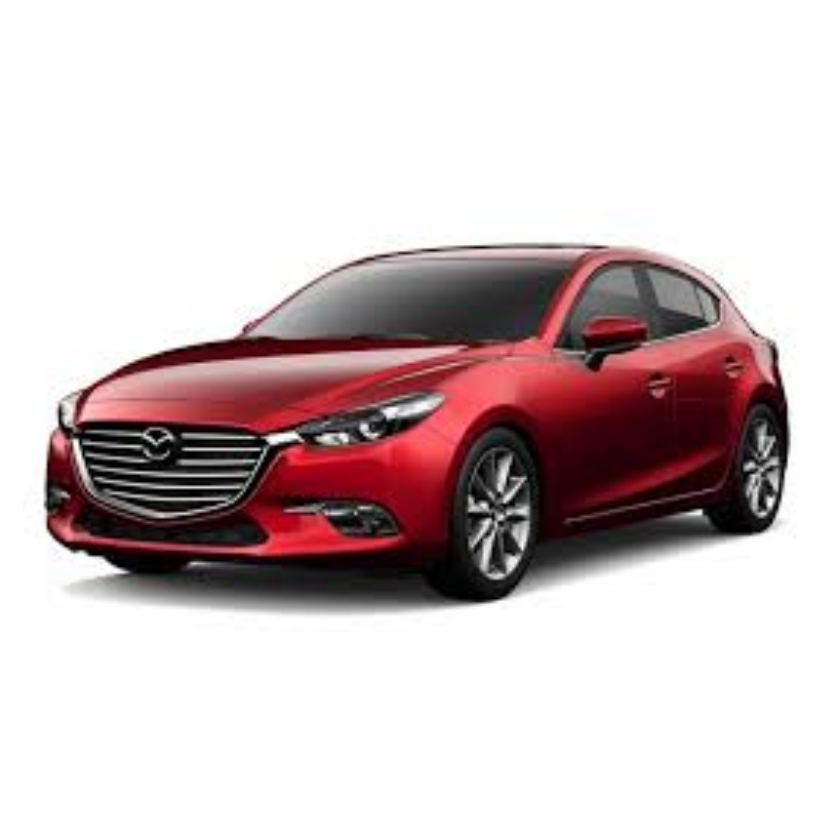

List of 12
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:281, 1:180, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 281 180 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:272, 1:185, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 272 185 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:341, 1:148, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 341 148 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:318, 1:159, 1:3] 0.255 0.255 0.255 0.259 0.259 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 318 159 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:275, 1:183, 1:3] 0.49 0.49 0.49 0.49 0.49 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 275 183 3
 $ :Formal class 'Image' [package "EBImage"]

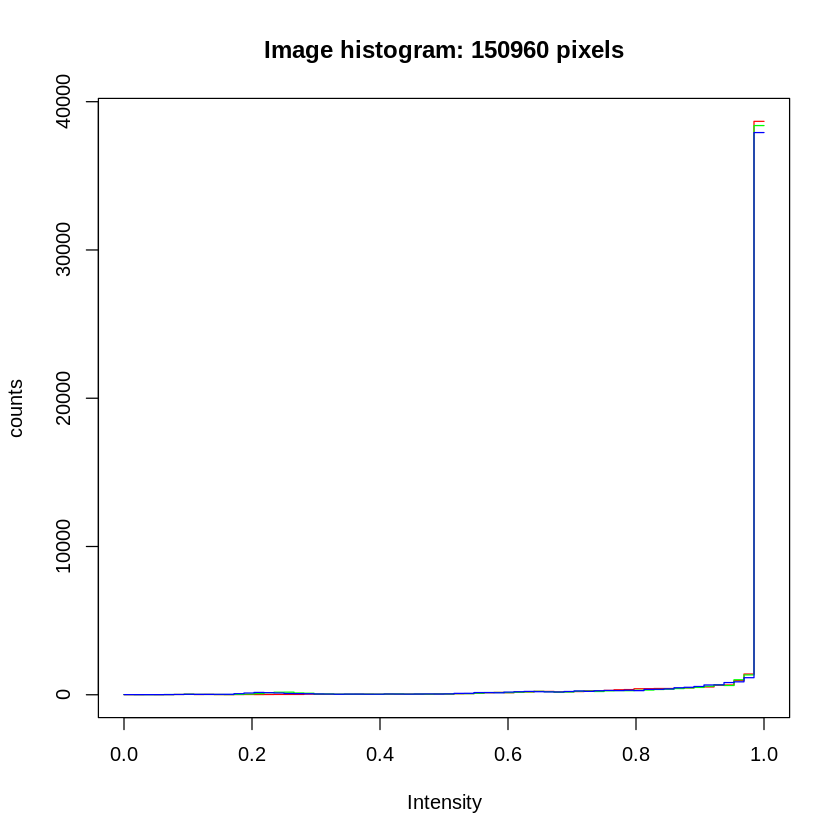

In [ ]:
# ============================================================
# CELL 9: EXPLORE
# ============================================================

print(mypic[[1]])

display(mypic[[8]])

summary(mypic[[1]])

hist(mypic[[2]])

str(mypic)

In [ ]:
# ============================================================
# CELL 10: RESIZE
# ============================================================

for (i in seq_along(mypic)) {

  mypic[[i]] <- resize(
    mypic[[i]],
    w = 28,
    h = 28
  )

}

cat("All images resized to 28 x 28.\n")

All images resized to 28 x 28.


In [ ]:
# ============================================================
# CELL 11: FLATTEN
# ============================================================

for (i in seq_along(mypic)) {

  img_array <- as.array(mypic[[i]])

  dims <- dim(img_array)

  cat(
    pics[i],
    ":",
    paste(dims, collapse = " x "),
    "\n"
  )

  if (length(dims) != 3) {
    stop(
      paste(
        pics[i],
        "is not a 3-dimensional RGB image."
      )
    )
  }

  if (dims[3] != 3) {
    stop(
      paste(
        pics[i],
        "does not have 3 color channels."
      )
    )
  }

  mypic[[i]] <- as.vector(img_array)
}

p1.jpg : 28 x 28 x 3 
p2.jpg : 28 x 28 x 3 
p3.jpg : 28 x 28 x 3 
p4.jpg : 28 x 28 x 3 
p5.jpg : 28 x 28 x 3 
p6.jpg : 28 x 28 x 3 
c1.jpg : 28 x 28 x 3 
c2.jpg : 28 x 28 x 3 
c3.jpg : 28 x 28 x 3 
c4.jpg : 28 x 28 x 3 
c5.jpg : 28 x 28 x 3 
c6.jpg : 28 x 28 x 3 


In [ ]:
# ============================================================
# CELL 12: CHECK FEATURES
# ============================================================

expected_features <- 28 * 28 * 3

cat(
  "Expected features:",
  expected_features,
  "\n"
)

cat(
  "First image features:",
  length(mypic[[1]]),
  "\n"
)

if (length(mypic[[1]]) != expected_features) {
  stop("Unexpected number of image features.")
}

Expected features: 2352 
First image features: 2352 


In [ ]:
# ============================================================
# CELL 13: TRAINING DATA
# ============================================================

trainx <- rbind(
  mypic[[1]],
  mypic[[2]],
  mypic[[3]],
  mypic[[4]],
  mypic[[5]],
  mypic[[7]],
  mypic[[8]],
  mypic[[9]],
  mypic[[10]],
  mypic[[11]]
)

testx <- rbind(
  mypic[[6]],
  mypic[[12]]
)

cat(
  "trainx:",
  paste(dim(trainx), collapse = " x "),
  "\n"
)

cat(
  "testx:",
  paste(dim(testx), collapse = " x "),
  "\n"
)

trainx: 10 x 2352 
testx: 2 x 2352 


In [ ]:
# ============================================================
# CELL 14: LABELS
# ============================================================

trainy <- c(
  0, 0, 0, 0, 0,
  1, 1, 1, 1, 1
)

testy <- c(
  0,
  1
)

In [ ]:
# ============================================================
# CELL 15: MATRICES
# ============================================================

trainx <- as.matrix(trainx)
testx <- as.matrix(testx)

cat(
  "Pixel range:",
  paste(range(trainx), collapse = " to "),
  "\n"
)

Pixel range: 0 to 1 


In [ ]:
# ============================================================
# CELL 16: ONE-HOT ENCODING
# ============================================================

trainLabels <- to_categorical(
  trainy,
  num_classes = 2
)

testLabels <- to_categorical(
  testy,
  num_classes = 2
)

cat("\nTraining labels:\n")
print(trainLabels)

cat("\nTest labels:\n")
print(testLabels)


Training labels:
      [,1] [,2]
 [1,]    1    0
 [2,]    1    0
 [3,]    1    0
 [4,]    1    0
 [5,]    1    0
 [6,]    0    1
 [7,]    0    1
 [8,]    0    1
 [9,]    0    1
[10,]    0    1

Test labels:
     [,1] [,2]
[1,]    1    0
[2,]    0    1


In [ ]:
# ============================================================
# CELL 17: MODEL
# ============================================================

model <- keras_model_sequential(
  input_shape = c(2352)
) |>
  layer_dense(
    units = 256,
    activation = "relu"
  ) |>
  layer_dense(
    units = 128,
    activation = "relu"
  ) |>
  layer_dense(
    units = 2,
    activation = "softmax"
  )

summary(model)

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 256)              │       602,368 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 2)                │           258 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 635,522 (2.42 MB)
 Trainable params: 635,522 (2.42 MB)
 Non-trainable params: 0 (0.00 B)


In [ ]:
# ============================================================
# CELL 18: COMPILE
# ============================================================

model |> compile(
  loss = loss_categorical_crossentropy(),
  optimizer = optimizer_rmsprop(),
  metrics = "accuracy"
)

In [ ]:
# ============================================================
# CELL 19: TRAIN
# ============================================================

history <- model |> fit(
  x = trainx,
  y = trainLabels,
  epochs = 30,
  batch_size = 32,
  validation_split = 0.2,
  verbose = 1
)

In [ ]:
# ============================================================
# CELL 20: EVALUATE TRAINING DATA
# ============================================================

model |> evaluate(
  trainx,
  trainLabels,
  verbose = 0
)

$accuracy
[1] 0.9

$loss
[1] 0.2018494

In [ ]:
# ============================================================
# CELL 21: PREDICT
# ============================================================

prob <- model |> predict(
  trainx,
  verbose = 0
)

pred <- max.col(prob) - 1

table(
  Predicted = pred,
  Actual = trainy
)

         Actual
Predicted 0 1
        0 5 1
        1 0 4

In [ ]:
# ============================================================
# CELL 22: PREDICTION PROBABILITIES
# ============================================================

results <- data.frame(
  Probability_Class_0 = prob[, 1],
  Probability_Class_1 = prob[, 2],
  Predicted = pred,
  Actual = trainy
)

print(results)

   Probability_Class_0 Probability_Class_1 Predicted Actual
1          0.994964778         0.005035220         0      0
2          0.996428967         0.003571011         0      0
3          0.996484995         0.003514949         0      0
4          0.988524437         0.011475605         0      0
5          0.990579665         0.009420315         0      0
6          0.021408835         0.978591144         1      1
7          0.002653322         0.997346699         1      1
8          0.011027779         0.988972187         1      1
9          0.012395354         0.987604618         1      1
10         0.855933607         0.144066438         0      1


In [ ]:
# ============================================================
# CELL 23: TEST SET
# ============================================================

test_eval <- model |> evaluate(
  testx,
  testLabels,
  verbose = 0
)

print(test_eval)

test_prob <- model |> predict(
  testx,
  verbose = 0
)

test_pred <- max.col(test_prob) - 1

test_results <- data.frame(
  Image = c("p6.jpg", "c6.jpg"),
  Probability_Class_0 = test_prob[, 1],
  Probability_Class_1 = test_prob[, 2],
  Predicted = test_pred,
  Actual = testy
)

print(test_results)

$accuracy
[1] 1

$loss
[1] 0.01419118

   Image Probability_Class_0 Probability_Class_1 Predicted Actual
1 p6.jpg          0.99642169         0.003578287         0      0
2 c6.jpg          0.02449267         0.975507319         1      1


In [ ]:
# ============================================================
# CELL 24: TEST CONFUSION MATRIX
# ============================================================

test_confusion <- table(
  Predicted = test_pred,
  Actual = testy
)

cat("\n========================================\n")
cat("TEST CONFUSION MATRIX\n")
cat("========================================\n")

print(test_confusion)


TEST CONFUSION MATRIX
         Actual
Predicted 0 1
        0 1 0
        1 0 1


In [ ]:
# ============================================================
# CELL 25: TEST ACCURACY
# ============================================================

test_accuracy <- mean(
  test_pred == testy
)

cat(
  "\nTest Accuracy:",
  round(test_accuracy * 100, 2),
  "%\n"
)


Test Accuracy: 100 %


In [ ]:
# ============================================================
# CELL 26: TEST PREDICTION DETAILS
# ============================================================

cat("\n========================================\n")
cat("TEST PREDICTION DETAILS\n")
cat("========================================\n")

for (i in seq_along(testy)) {

  cat("\nImage:", test_results$Image[i], "\n")

  cat(
    "Actual class:",
    test_results$Actual[i],
    "\n"
  )

  cat(
    "Predicted class:",
    test_results$Predicted[i],
    "\n"
  )

  cat(
    "Probability of class 0:",
    round(
      test_results$Probability_Class_0[i],
      4
    ),
    "\n"
  )

  cat(
    "Probability of class 1:",
    round(
      test_results$Probability_Class_1[i],
      4
    ),
    "\n"
  )

  if (
    test_results$Predicted[i] ==
    test_results$Actual[i]
  ) {

    cat("Result: CORRECT\n")

  } else {

    cat("Result: INCORRECT\n")
  }
}


TEST PREDICTION DETAILS

Image: p6.jpg 
Actual class: 0 
Predicted class: 0 
Probability of class 0: 0.9964 
Probability of class 1: 0.0036 
Result: CORRECT

Image: c6.jpg 
Actual class: 1 
Predicted class: 1 
Probability of class 0: 0.0245 
Probability of class 1: 0.9755 
Result: CORRECT


In [ ]:
# ============================================================
# CELL 27: TRAINING CONFUSION MATRIX
# ============================================================

train_confusion <- table(
  Predicted = pred,
  Actual = trainy
)

cat("\n========================================\n")
cat("TRAINING CONFUSION MATRIX\n")
cat("========================================\n")

print(train_confusion)


TRAINING CONFUSION MATRIX
         Actual
Predicted 0 1
        0 5 1
        1 0 4


In [ ]:
# ============================================================
# CELL 28: TRAINING ACCURACY
# ============================================================

train_accuracy <- mean(
  pred == trainy
)

cat(
  "\nTraining Accuracy:",
  round(train_accuracy * 100, 2),
  "%\n"
)


Training Accuracy: 90 %


In [ ]:
# ============================================================
# CELL 29: TRAINING RESULTS
# ============================================================

cat("\n========================================\n")
cat("TRAINING PREDICTIONS\n")
cat("========================================\n")

print(results)


TRAINING PREDICTIONS
   Probability_Class_0 Probability_Class_1 Predicted Actual
1          0.994964778         0.005035220         0      0
2          0.996428967         0.003571011         0      0
3          0.996484995         0.003514949         0      0
4          0.988524437         0.011475605         0      0
5          0.990579665         0.009420315         0      0
6          0.021408835         0.978591144         1      1
7          0.002653322         0.997346699         1      1
8          0.011027779         0.988972187         1      1
9          0.012395354         0.987604618         1      1
10         0.855933607         0.144066438         0      1


In [ ]:
# ============================================================
# CELL 30: TEST RESULTS
# ============================================================

cat("\n========================================\n")
cat("TEST PREDICTIONS\n")
cat("========================================\n")

print(test_results)


TEST PREDICTIONS
   Image Probability_Class_0 Probability_Class_1 Predicted Actual
1 p6.jpg          0.99642169         0.003578287         0      0
2 c6.jpg          0.02449267         0.975507319         1      1


In [ ]:
# ============================================================
# CELL 31: MODEL SUMMARY
# ============================================================

cat("\n========================================\n")
cat("MODEL SUMMARY\n")
cat("========================================\n")

cat(
  "Input features:",
  ncol(trainx),
  "\n"
)

cat(
  "Hidden layer 1:",
  "256 neurons, ReLU",
  "\n"
)

cat(
  "Hidden layer 2:",
  "128 neurons, ReLU",
  "\n"
)

cat(
  "Output layer:",
  "2 neurons, Softmax",
  "\n"
)

cat(
  "Optimizer:",
  "RMSprop",
  "\n"
)

cat(
  "Epochs:",
  "30",
  "\n"
)

cat(
  "Batch size:",
  "32",
  "\n"
)


MODEL SUMMARY
Input features: 2352 
Hidden layer 1: 256 neurons, ReLU 
Hidden layer 2: 128 neurons, ReLU 
Output layer: 2 neurons, Softmax 
Optimizer: RMSprop 
Epochs: 30 
Batch size: 32 


In [ ]:
# ============================================================
# CELL 32: FINAL ACCURACY SUMMARY
# ============================================================

cat("\n========================================\n")
cat("FINAL ACCURACY SUMMARY\n")
cat("========================================\n")

cat(
  "Training accuracy:",
  round(train_accuracy * 100, 2),
  "%\n"
)

cat(
  "Test accuracy:",
  round(test_accuracy * 100, 2),
  "%\n"
)


FINAL ACCURACY SUMMARY
Training accuracy: 90 %
Test accuracy: 100 %


In [ ]:
# ============================================================
# CELL 33: FINAL RESULT TABLE
# ============================================================

final_results <- data.frame(
  Dataset = c(
    "Training",
    "Test"
  ),
  Number_of_Images = c(
    length(trainy),
    length(testy)
  ),
  Accuracy = c(
    train_accuracy,
    test_accuracy
  )
)

final_results$Accuracy_Percent <- round(
  final_results$Accuracy * 100,
  2
)

cat("\n========================================\n")
cat("FINAL RESULTS\n")
cat("========================================\n")

print(final_results)


FINAL RESULTS
   Dataset Number_of_Images Accuracy Accuracy_Percent
1 Training               10      0.9               90
2     Test                2      1.0              100


In [ ]:
# ============================================================
# CELL 34: SAVE MODEL
# ============================================================

model_path <- "/content/image_classifier.keras"

save_model(
  model,
  model_path
)

cat(
  "\nModel saved to:",
  model_path,
  "\n"
)


Model saved to: /content/image_classifier.keras 


In [ ]:
# ============================================================
# CELL 35: SAVE TEST RESULTS
# ============================================================

results_path <- "/content/test_predictions.csv"

write.csv(
  test_results,
  results_path,
  row.names = FALSE
)

cat(
  "\nTest predictions saved to:",
  results_path,
  "\n"
)


Test predictions saved to: /content/test_predictions.csv 


In [ ]:
# ============================================================
# CELL 36: FINAL REPORT
# ============================================================

cat("\n")
cat("============================================================\n")
cat("                 IMAGE CLASSIFICATION REPORT\n")
cat("============================================================\n")

cat("\nDataset:\n")
cat("  Training images:", length(trainy), "\n")
cat("  Test images:", length(testy), "\n")

cat("\nImage dimensions:\n")
cat("  Width:  28 pixels\n")
cat("  Height: 28 pixels\n")
cat("  Channels: 3 (RGB)\n")
cat("  Features per image: 2352\n")

cat("\nClasses:\n")
cat("  Class 0 = p images\n")
cat("  Class 1 = c images\n")

cat("\nModel:\n")
cat("  Dense(256, ReLU)\n")
cat("  Dense(128, ReLU)\n")
cat("  Dense(2, Softmax)\n")
cat("  Optimizer: RMSprop\n")
cat("  Epochs: 30\n")
cat("  Batch size: 32\n")

cat("\nPerformance:\n")
cat(
  "  Training accuracy:",
  round(train_accuracy * 100, 2),
  "%\n"
)

cat(
  "  Test accuracy:",
  round(test_accuracy * 100, 2),
  "%\n"
)

cat("\nTest predictions:\n")
print(test_results)

cat("\n============================================================\n")
cat("                     END OF ANALYSIS\n")
cat("============================================================\n")


                 IMAGE CLASSIFICATION REPORT

Dataset:
  Training images: 10 
  Test images: 2 

Image dimensions:
  Width:  28 pixels
  Height: 28 pixels
  Channels: 3 (RGB)
  Features per image: 2352

Classes:
  Class 0 = p images
  Class 1 = c images

Model:
  Dense(256, ReLU)
  Dense(128, ReLU)
  Dense(2, Softmax)
  Optimizer: RMSprop
  Epochs: 30
  Batch size: 32

Performance:
  Training accuracy: 90 %
  Test accuracy: 100 %

Test predictions:
   Image Probability_Class_0 Probability_Class_1 Predicted Actual
1 p6.jpg          0.99642169         0.003578287         0      0
2 c6.jpg          0.02449267         0.975507319         1      1

                     END OF ANALYSIS
